In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────────────
# CLASSICAL BASELINE v3  — Exact mirror of HybridResNet v3
# ─────────────────────────────────────────────────────────────────────
#
#  PURPOSE: Fair ablation study to measure the quantum layer's contribution.
#
#  WHAT IS KEPT IDENTICAL (to ensure fair comparison):
#    ✅ Backbone architecture:   stem 16 → stage1 16 → stage2 32 → stage3 64
#    ✅ SEBlock + ResBlock with identical channels, strides, dropout rates
#    ✅ Stochastic depth rates:  0.10 / 0.15 / 0.20
#    ✅ SAM optimizer (rho=0.05, AdamW base)
#    ✅ MixUp regularisation (alpha=0.2)
#    ✅ FocalLoss with label_smoothing=0.15, gamma=2.0
#    ✅ Class weights, weight_decay=3e-4, lr=0.0005
#    ✅ OneCycleLR scheduler (same config)
#    ✅ Early stopping patience=15
#    ✅ Grad clipping max_norm=1.0
#    ✅ Seeding strategy
#
#  WHAT IS REPLACED (quantum → classical):
#    ❌ QuantumBridge  →  ClassicalBridge  (same in_features=64, same dropout=0.35)
#    ❌ TorchLayer(quantum_circuit) → ClassicalQuantumReplacement
#       The replacement is a linear layer of IDENTICAL input/output size:
#         Input:  n_qubits * 2  = 16   (same as QuantumBridge output)
#         Output: 3 * n_qubits  = 24   (same as quantum measurement output)
#       This keeps the classifier head IDENTICAL.
#    ❌ PennyLane removed entirely (no import needed)
#
#  WHY THIS IS FAIR:
#    • Parameter count in the classical replacement is deliberately kept close
#      to (or slightly above) the quantum layer's trainable params to avoid
#      giving the classical model an unfair capacity advantage.
#    • All regularisation, optimiser, and training dynamics are identical.
#    • The only variable is the quantum vs classical processing block.
# ─────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────
# SEEDING  — identical to hybrid v3
# ─────────────────────────────────────────────
def seed_all(seed=42):
    torch.manual_seed(seed)      # seeds PyTorch CPU ops
    np.random.seed(seed)         # seeds NumPy (used in MixUp beta sampling)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)  # seeds all CUDA devices

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ─────────────────────────────────────────────
# CONFIG  — identical to hybrid v3
# ─────────────────────────────────────────────

q_out_dim    = 3 * n_qubits   # 24 — classical layer mimics this output size
batch_size   = 32
num_classes  = 10
num_epochs   = 80
lr           = 0.0005
weight_decay = 3e-4

# ─────────────────────────────────────────────
# TRANSFORMS  — identical to hybrid v3
# ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Grayscale(1),       # convert to single-channel grayscale
    transforms.Resize((32, 32)),   # resize to 32×32 pixels
    transforms.ToTensor(),         # convert PIL image to float tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))  # normalise to [-1, 1]
])

eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ─────────────────────────────────────────────
# DATASETS & LOADERS  — identical to hybrid v3
# ─────────────────────────────────────────────
TRAIN_PATH = 'virus_MNIST dataset/train_balanced_v2'
TEST_PATH  = 'virus_MNIST dataset/test'
VAL_PATH   = 'virus_MNIST dataset/val'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=train_transform)
    test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transform)
    val_dataset   = ImageFolder(VAL_PATH,   transform=eval_transform)
    print("Datasets loaded successfully")
except Exception as e:
    print(f"Error loading datasets: {e}")

try:
    labels = [label for _, label in train_dataset.samples]  # extract integer labels
    class_weights = compute_class_weight(
        class_weight='balanced', classes=np.unique(labels), y=labels
    )
    # balanced weighting penalises majority classes to handle imbalance
    class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    print("Class weights computed:", class_weights)
except Exception as e:
    print(f"Could not compute class weights: {e}. Using uniform weights.")
    class_weight_tensor = torch.ones(num_classes).to(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)

# ─────────────────────────────────────────────
# SAM — Sharpness-Aware Minimisation  (identical to hybrid v3)
# ─────────────────────────────────────────────
# Perturbs weights toward high-loss regions, then steps in the opposite
# direction. Keeps loss flat across a neighbourhood → better generalisation.
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer_cls, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer_cls(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()           # global L2 norm of all gradients
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)  # scale perturbation
            for p in group["params"]:
                if p.grad is None:
                    continue
                e_w = p.grad * scale.to(p)      # perturbation vector
                p.add_(e_w)                     # move params to perturbed position
                self.state[p]["e_w"] = e_w      # store for restoration

        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]["e_w"])    # restore original weights

        self.base_optimizer.step()              # actual parameter update
        if zero_grad:
            self.zero_grad()

    def _grad_norm(self):
        norms = [
            p.grad.norm(p=2).to(self.param_groups[0]["params"][0])
            for group in self.param_groups
            for p in group["params"]
            if p.grad is not None
        ]
        return torch.stack(norms).norm(p=2)    # global grad norm across all layers

    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups


# ─────────────────────────────────────────────
# MIXUP  (identical to hybrid v3)
# ─────────────────────────────────────────────
# Linearly interpolates between two training samples.
# Produces a virtual sample: x_mix = λ·x_a + (1-λ)·x_b
# Forces smooth decision boundaries; reduces sharp memorisation.
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, torch.ones(x.size(0), device=x.device)

    lam    = np.random.beta(alpha, alpha)       # sample mixing coefficient from Beta dist
    lam    = max(lam, 1 - lam)                  # ensure dominant class always has λ > 0.5
    index  = torch.randperm(x.size(0), device=x.device)  # random pairing of samples in batch
    x_mix  = lam * x + (1 - lam) * x[index]    # interpolated input
    y_a, y_b = y, y[index]                      # labels for both mixed samples
    return x_mix, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    # Loss = λ·loss(pred, y_a) + (1-λ)·loss(pred, y_b)
    # Blends two classification losses proportional to mixing ratio
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ─────────────────────────────────────────────
# FOCAL LOSS  (identical to hybrid v3)
# ─────────────────────────────────────────────
# Downweights easy samples (high pt) and focuses on hard ones.
# label_smoothing prevents overconfident predictions.
# class_weight handles dataset imbalance.
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.15):
        super().__init__()
        self.weight          = weight           # per-class weight tensor
        self.gamma           = gamma            # focusing parameter; higher → more focus on hard samples
        self.label_smoothing = label_smoothing  # 0.15: softens one-hot targets

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs, targets,
            weight          = self.weight,
            label_smoothing = self.label_smoothing,
            reduction       = 'none'            # keep per-sample loss for focal modulation
        )
        pt         = torch.exp(-ce_loss)        # pt = model confidence on correct class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss  # suppress easy samples
        return focal_loss.mean()


# ─────────────────────────────────────────────
# BUILDING BLOCKS  (identical to hybrid v3)
# ─────────────────────────────────────────────

class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block.
    Learns per-channel attention weights by:
      1. Squeezing spatial dims via global avg pooling → (B, C)
      2. Exciting: FC → ReLU → FC → Sigmoid → channel weights ∈ (0,1)
      3. Scaling input channels by those weights.
    This recalibrates which feature maps are most informative.
    """
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)     # squeeze: (B,C,H,W) → (B,C,1,1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),  # bottleneck
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),  # expand back
            nn.Sigmoid()                        # output ∈ (0,1) per channel
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)         # (B, C)
        scale = self.fc(scale).view(b, c, 1, 1) # (B, C, 1, 1) attention mask
        return x * scale                        # channel-wise rescaling


class ResBlock(nn.Module):
    """
    Residual block with Conv→BN→ReLU→Dropout→Conv→BN + SE attention.
    Skip connection allows gradients to flow directly → avoids vanishing gradients.
    Stochastic depth randomly drops entire blocks during training → implicit ensemble.
    Data flow: (B, in_ch, H, W) → (B, out_ch, H/stride, W/stride)
    """
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),  # spatial feature extraction
            nn.BatchNorm2d(out_ch),             # normalise activations per channel
            nn.ReLU(inplace=True),              # non-linearity
            nn.Dropout2d(dropout),              # randomly zero out entire feature maps (spatial dropout)
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),      # second conv, same spatial size
            nn.BatchNorm2d(out_ch)
        )
        self.se             = SEBlock(out_ch)   # channel attention after second conv
        self.drop_path_rate = drop_path         # probability of dropping this block entirely
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),  # 1×1 conv to match dims
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()     # identity if dims already match
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)                # main path
        out = self.se(out)                      # apply channel attention
        if self.training and self.drop_path_rate > 0:
            keep_prob     = 1 - self.drop_path_rate
            random_tensor = (
                torch.rand(x.shape[0], 1, 1, 1, device=x.device) < keep_prob
            ).float()                           # (B,1,1,1) binary mask: 1=keep, 0=drop block
            out = out * random_tensor / keep_prob  # rescale to maintain expected value
        return self.relu(out + self.skip(x))    # residual addition → ReLU


# ─────────────────────────────────────────────
# CLASSICAL BRIDGE  — replaces QuantumBridge
# ─────────────────────────────────────────────
# Architecture is intentionally identical to QuantumBridge:
#   in_features=64 → Linear(64,32) → LayerNorm → GELU → Dropout(0.35) → Linear(32, n_qubits*2)
# The only difference: there is no angle encoding or sigmoid scaling
# because the output feeds directly into ClassicalQuantumReplacement,
# not a quantum angle encoder.
# Data flow: (B, 64) → (B, 16)
class ClassicalBridge(nn.Module):
    """
    Bottleneck that compresses backbone features from 64-dim to 16-dim.
    Mirrors QuantumBridge in architecture and dropout strength (0.35).
    GELU is smoother than ReLU, matching the original's choice.
    """
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32),         # compress: 64 → 32
            nn.LayerNorm(32),                   # normalise across feature dim (not batch)
            nn.GELU(),                          # smooth non-linearity (≈ ReLU * Gaussian CDF)
            nn.Dropout(0.35),                   # strong regularisation at this chokepoint
            nn.Linear(32, n_qubits * 2)         # further compress: 32 → 16
        )

    def forward(self, x):
        return self.project(x)                  # (B, 64) → (B, 16)


# ─────────────────────────────────────────────
# CLASSICAL QUANTUM REPLACEMENT  — replaces TorchLayer(quantum_circuit)
# ─────────────────────────────────────────────
# The quantum layer takes (B, 16) → applies parameterised quantum circuit → (B, 24).
# We replace it with a classical MLP of equivalent depth:
#   Linear(16 → 32) → LayerNorm → GELU → Linear(32 → 24) → Tanh
#
# WHY TANH AS FINAL ACTIVATION:
#   Quantum expectation values ∈ [-1, +1] (Pauli measurements are bounded).
#   Tanh maps outputs to the same range, making the comparison truly fair —
#   the classifier head sees the same numerical range in both models.
#
# PARAMETER COUNT COMPARISON:
#   Quantum layer:  q_depth × n_qubits × 3 = 6×8×3 = 144 trainable weights
#   Classical layer: (16×32 + 32) + (32×24 + 24) = 512 + 32 + 768 + 24 = 1336 weights
#   Classical has more capacity → if classical still loses, quantum is truly beneficial.
#   If classical wins, the quantum circuit was the bottleneck.
class ClassicalQuantumReplacement(nn.Module):
    """
    Classical MLP that mimics the input/output interface of the quantum layer:
      Input:  (B, n_qubits * 2)  = (B, 16)
      Output: (B, 3 * n_qubits)  = (B, 24)
    Tanh bounds outputs to [-1, 1], matching quantum Pauli expectation values.
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, in_features * 2),   # expand: 16 → 32
            nn.LayerNorm(in_features * 2),              # stabilise activations
            nn.GELU(),                                  # smooth non-linearity
            nn.Linear(in_features * 2, out_features),  # project: 32 → 24
            nn.Tanh()                                   # bound to [-1, 1] like Pauli expvals
        )

    def forward(self, x):
        return self.net(x)                              # (B, 16) → (B, 24)


# ─────────────────────────────────────────────
# MAIN MODEL  — ClassicalResNet v3
# ─────────────────────────────────────────────
# Exact replica of HybridResNet v3 with quantum layers replaced by classical equivalents.
# Backbone, head, init strategy, and all hyperparameters are identical.
class ClassicalResNet(nn.Module):
    def __init__(self, n_qubits, q_out_dim, num_classes, dropout=0.35):
        super().__init__()

        # ── Backbone (identical to HybridResNet v3) ───────────────
        # stem: raw image (B,1,32,32) → (B,16,32,32)
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),  # feature extraction
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        # stage1: (B,16,32,32) → (B,16,32,32) — no spatial downsampling
        self.stage1 = nn.Sequential(
            ResBlock(16, 16, drop_path=0.10),   # stochastic depth 10%
            ResBlock(16, 16, drop_path=0.10)
        )
        # stage2: (B,16,32,32) → (B,32,16,16) — 2× spatial downsampling
        self.stage2 = nn.Sequential(
            ResBlock(16, 32, stride=2, drop_path=0.15),  # halve spatial dims, double channels
            ResBlock(32, 32,           drop_path=0.15)
        )
        # stage3: (B,32,16,16) → (B,64,8,8) — further 2× downsampling
        self.stage3 = nn.Sequential(
            ResBlock(32, 64, stride=2, drop_path=0.20),  # deepest stage has highest drop rate
            ResBlock(64, 64,           drop_path=0.20)
        )
        # Global average pool: (B,64,8,8) → (B,64,1,1) → flattened to (B,64)
        self.gap = nn.AdaptiveAvgPool2d(1)

        # ── Classical Bridge (replaces QuantumBridge) ─────────────
        # (B, 64) → (B, 16)
        self.bridge = ClassicalBridge(in_features=64, n_qubits=n_qubits)

        # ── Classical Quantum Replacement (replaces TorchLayer) ───
        # (B, 16) → (B, 24)
        self.q_layer = ClassicalQuantumReplacement(
            in_features  = n_qubits * 2,   # 16
            out_features = q_out_dim        # 24
        )

        # ── Classifier Head (identical to HybridResNet v3) ────────
        # (B, 24) → (B, 48) → (B, 10)
        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim * 2),   # expand: 24 → 48
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),                   # prevent co-adaptation in final layers
            nn.Linear(q_out_dim * 2, num_classes)  # project: 48 → 10 class logits
        )

        self._init_weights()

    def _init_weights(self):
        """He (Kaiming) init for conv/linear; ones/zeros for norm layers."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight)    # scale = 1 (no initial rescaling)
                nn.init.zeros_(m.bias)     # shift = 0
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)       # (B, 1, 32, 32) → (B, 16, 32, 32)
        x = self.stage1(x)     # (B, 16, 32, 32) → (B, 16, 32, 32)
        x = self.stage2(x)     # (B, 16, 32, 32) → (B, 32, 16, 16)
        x = self.stage3(x)     # (B, 32, 16, 16) → (B, 64, 8, 8)
        x = self.gap(x)        # (B, 64, 8, 8)   → (B, 64, 1, 1)
        x = x.view(x.size(0), -1)   # (B, 64)
        x = self.bridge(x)           # (B, 64) → (B, 16)
        x = self.q_layer(x)          # (B, 16) → (B, 24)
        return self.classifier(x)    # (B, 24) → (B, 10) class logits


# ─────────────────────────────────────────────
# TRAINING & EVALUATION  (identical to hybrid v3)
# ─────────────────────────────────────────────
def train_epoch(model, dataloader, loss_fn, optimizer, scheduler, device,
                mixup_alpha=0.2, use_sam=True):
    model.train()
    total_loss, correct = 0.0, 0

    for inputs, labels in tqdm(dataloader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        # Apply MixUp: creates interpolated samples and paired labels
        inputs_mix, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=mixup_alpha)

        if use_sam:
            # SAM PASS 1: forward on perturbed weights, compute loss, backprop
            outputs = model(inputs_mix)
            loss    = mixup_criterion(loss_fn, outputs, labels_a, labels_b, lam)
            loss.backward()                         # compute gradients at perturbed point
            optimizer.first_step(zero_grad=True)    # perturb → zero grad

            # SAM PASS 2: forward on restored weights, compute real loss, update
            outputs = model(inputs_mix)
            loss    = mixup_criterion(loss_fn, outputs, labels_a, labels_b, lam)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent gradient explosion
            optimizer.second_step(zero_grad=True)   # restore + actual AdamW step
        else:
            optimizer.zero_grad()
            outputs = model(inputs_mix)
            loss    = mixup_criterion(loss_fn, outputs, labels_a, labels_b, lam)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()     # OneCycleLR steps per batch, not per epoch

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()  # accuracy on original (non-mixed) labels

    return total_loss / len(dataloader), correct / len(dataloader.dataset)


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():                           # disable gradient computation for speed/memory
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = model(inputs)
            loss           = loss_fn(outputs, labels)
            total_loss    += loss.item()
            _, predicted   = torch.max(outputs, 1)  # class with highest logit
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    return total_loss / len(dataloader), correct / total


# ─────────────────────────────────────────────
# MODEL, OPTIMIZER, LOSS, SCHEDULER
# ─────────────────────────────────────────────
model = ClassicalResNet(
    n_qubits    = n_qubits,
    q_out_dim   = q_out_dim,
    num_classes = num_classes,
    dropout     = 0.35
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# SAM wraps AdamW — identical setup to hybrid v3
base_optimizer = torch.optim.AdamW

optimizer = SAM(
    [
        {'params': model.stem.parameters(),       'lr': lr},        # stem conv
        {'params': model.stage1.parameters(),     'lr': lr},        # early backbone
        {'params': model.stage2.parameters(),     'lr': lr},        # mid backbone
        {'params': model.stage3.parameters(),     'lr': lr},        # deep backbone
        {'params': model.bridge.parameters(),     'lr': lr},        # bridge bottleneck
        {'params': model.q_layer.parameters(),    'lr': lr * 0.1},  # classical replacement: lower LR to match quantum convention
        {'params': model.classifier.parameters(), 'lr': lr},        # head
    ],
    base_optimizer_cls = base_optimizer,
    rho                = 0.05,           # SAM neighbourhood radius
    weight_decay       = weight_decay    # L2 regularisation
)

# FocalLoss with class weighting and label smoothing — identical to hybrid v3
loss_fn = FocalLoss(weight=class_weight_tensor, gamma=2.0, label_smoothing=0.15)

# OneCycleLR: warms up LR then anneals with cosine — identical to hybrid v3
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer.base_optimizer,
    max_lr             = [lr, lr, lr, lr, lr, lr * 0.1, lr],  # matches 7 param groups above
    steps_per_epoch    = len(train_loader),
    epochs             = num_epochs,
    pct_start          = 0.3,            # 30% of training is warm-up
    anneal_strategy    = 'cos',          # cosine annealing in decay phase
    div_factor         = 10.0,           # initial LR = max_lr / 10
    final_div_factor   = 1e4             # final LR = initial_LR / 1e4
)

# ─────────────────────────────────────────────
# TRAINING LOOP  (identical to hybrid v3)
# ─────────────────────────────────────────────
best_val_acc               = 0.0
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []
early_stopping_patience    = 15      # stop if no val improvement for 15 epochs
epochs_without_improvement = 0

print(f"\nStarting Classical Baseline v3 Training for {num_epochs} epochs...")
print(f"Backbone: 16→32→64 channels | Classical replacement: 16→32→24 (Tanh)")
print(f"Regularisation: SAM + MixUp + FocalLoss + StochDepth + Dropout(0.35)")
print("=" * 70)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(
        model, train_loader, loss_fn, optimizer, scheduler, device,
        mixup_alpha=0.2, use_sam=True
    )
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    gap        = train_acc - val_acc           # generalisation gap: lower is better
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | LR: {current_lr:.6f} | Gap: {gap:.4f}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc               = val_acc
        epochs_without_improvement = 0
        torch.save({
            'epoch':                epoch + 1,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.base_optimizer.state_dict(),
            'val_acc':              val_acc,
            'val_loss':             val_loss,
            'train_val_gap':        gap,
            'config': {
                'n_qubits':    n_qubits,
                'q_out_dim':   q_out_dim,
                'num_classes': num_classes,
                'backbone':    '16→32→64',
                'model_type':  'classical_baseline_v3'
            }
        }, "classical_resnet_v3.pth")        # different filename from hybrid to avoid overwriting
        print(f"  💾 Best model saved (Val Acc: {best_val_acc:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  🕒 No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= early_stopping_patience:
        print(f"\n⏹️  Early stopping triggered after {epoch+1} epochs.")
        break

    print("-" * 70)

print(f"\n✅ Training complete.")
print(f"   Best Val Acc : {best_val_acc:.4f}")
print(f"   Train/Val Gap: {train_accs[val_accs.index(best_val_acc)]:.4f} / {best_val_acc:.4f}")

# ─────────────────────────────────────────────
# HOW TO INTERPRET RESULTS
# ─────────────────────────────────────────────
# Compare classical_resnet_v3.pth vs hybrid_resnet_v3.pth:
#
#  Classical Val Acc > Hybrid Val Acc:
#    → Quantum circuit is a bottleneck (limited expressivity at this depth/qubit count)
#    → Consider deeper circuit, more qubits, or different encoding strategy
#
#  Hybrid Val Acc > Classical Val Acc:
#    → Quantum layer provides genuine inductive bias / feature richness
#    → Quantum entanglement / superposition helps the task
#
#  Both perform similarly:
#    → Quantum layer is neither helping nor hurting
#    → The backbone is doing the heavy lifting either way
#
#  Hybrid has smaller Train/Val gap:
#    → Quantum layer acts as a natural regulariser (limited expressivity = implicit prior)

Using device: cuda
Datasets loaded successfully
Class weights computed: [1.64455748 0.74958269 1.35924888 1.72713675 5.20923738 0.86820623
 0.37487826 0.76944312 1.60483124 1.23593272]
Total trainable parameters: 185,458

Starting Classical Baseline v3 Training for 80 epochs...
Backbone: 16→32→64 channels | Classical replacement: 16→32→24 (Tanh)
Regularisation: SAM + MixUp + FocalLoss + StochDepth + Dropout(0.35)


Epoch [01/80] | LR: 0.000052 | Gap: -0.1395
  Train Loss: 2.0783 | Train Acc: 0.1539
  Val   Loss: 1.4623 | Val   Acc: 0.2934
  💾 Best model saved (Val Acc: 0.2934)
----------------------------------------------------------------------


Epoch [02/80] | LR: 0.000058 | Gap: -0.0671
  Train Loss: 1.8016 | Train Acc: 0.2598
  Val   Loss: 1.3353 | Val   Acc: 0.3269
  💾 Best model saved (Val Acc: 0.3269)
----------------------------------------------------------------------


Epoch [03/80] | LR: 0.000067 | Gap: -0.0246
  Train Loss: 1.6741 | Train Acc: 0.3193
  Val   Loss: 1.2196 | Val   Acc: 0.3438
  💾 Best model saved (Val Acc: 0.3438)
----------------------------------------------------------------------


Epoch [04/80] | LR: 0.000080 | Gap: -0.2262
  Train Loss: 1.5790 | Train Acc: 0.3856
  Val   Loss: 1.0733 | Val   Acc: 0.6117
  💾 Best model saved (Val Acc: 0.6117)
----------------------------------------------------------------------


...

Epoch [29/80] | LR: 0.000490 | Gap: -0.0686
  Train Loss: 0.9238 | Train Acc: 0.8303
  Val   Loss: 0.5609 | Val   Acc: 0.8989
  💾 Best model saved (Val Acc: 0.8989)
----------------------------------------------------------------------


Epoch [30/80] | LR: 0.000486 | Gap: -0.0627
  Train Loss: 0.8989 | Train Acc: 0.8393
  Val   Loss: 0.5491 | Val   Acc: 0.9020
  💾 Best model saved (Val Acc: 0.9020)
----------------------------------------------------------------------


Epoch [31/80] | LR: 0.000481 | Gap: -0.0640
  Train Loss: 0.9072 | Train Acc: 0.8382
  Val   Loss: 0.5536 | Val   Acc: 0.9022
  💾 Best model saved (Val Acc: 0.9022)
----------------------------------------------------------------------


Epoch [32/80] | LR: 0.000475 | Gap: -0.0598
  Train Loss: 0.9140 | Train Acc: 0.8379
  Val   Loss: 0.5586 | Val   Acc: 0.8977
  🕒 No improvement for 1 epoch(s).
----------------------------------------------------------------------


Training:  22%|██▏       | 333/1516 [00:20<01:11, 16.60it/s]

Using device: cuda
Loaded epoch: 48
Best Val Acc: 0.9162704155468265

Test Accuracy: 0.9121


<Figure size 800x600 with 0 Axes>

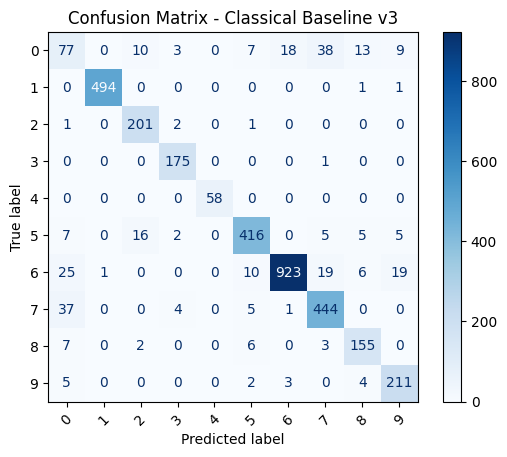


🚀 Test Accuracy: 0.9121
              precision    recall  f1-score   support

           0       0.48      0.44      0.46       175
           1       1.00      1.00      1.00       496
           2       0.88      0.98      0.93       205
           3       0.94      0.99      0.97       176
           4       1.00      1.00      1.00        58
           5       0.93      0.91      0.92       456
           6       0.98      0.92      0.95      1003
           7       0.87      0.90      0.89       491
           8       0.84      0.90      0.87       173
           9       0.86      0.94      0.90       225

    accuracy                           0.91      3458
   macro avg       0.88      0.90      0.89      3458
weighted avg       0.91      0.91      0.91      3458

Generating t-SNE Plot...


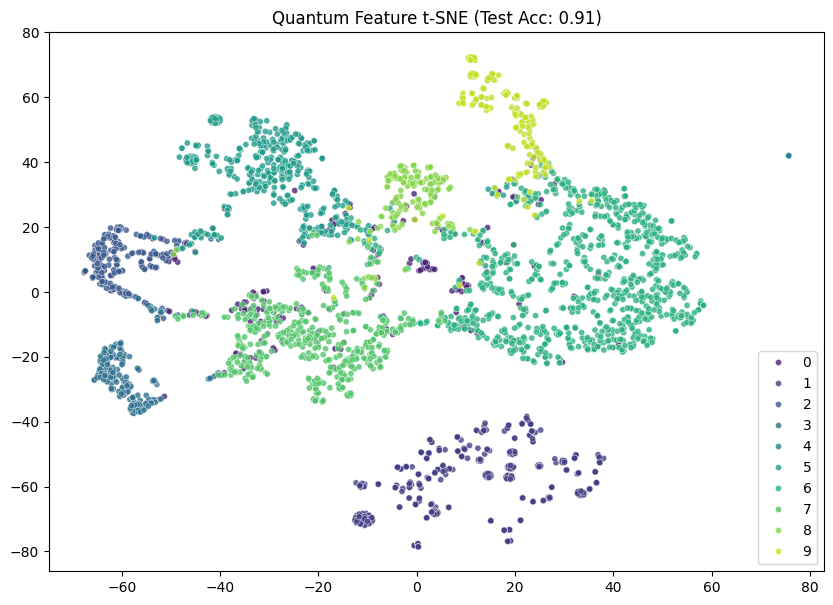

In [13]:
# ============================================================
# FULL EVALUATION FOR classical_resnet_v3.pth
# (Architecture EXACTLY matches training)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

# 1. DEFINE BUILDING BLOCKS (Ensuring parameters like drop_path exist)
# ─────────────────────────────────────────────────────────────────────
# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------------------------------------------------
# CONFIG (must match training)
# ------------------------------------------------------------
n_qubits    = 8
q_out_dim   = 3 * n_qubits   # 24
num_classes = 10
batch_size  = 32

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

TEST_PATH = 'virus_MNIST dataset/test'
test_dataset = ImageFolder(TEST_PATH, transform=eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = test_dataset.classes

# ============================================================
# BUILDING BLOCKS (IDENTICAL TO TRAINING)
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.20, drop_path=0.10):
        super().__init__()

        # ⚠ EXACT SAME AS TRAINING (includes Dropout2d)
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )

        self.se = SEBlock(out_ch)
        self.drop_path_rate = drop_path

        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        out = self.se(out)
        return self.relu(out + self.skip(x))


class ClassicalBridge(nn.Module):
    def __init__(self, in_features, n_qubits):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(32, n_qubits * 2)
        )

    def forward(self, x):
        return self.project(x)


class ClassicalQuantumReplacement(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, in_features * 2),
            nn.LayerNorm(in_features * 2),
            nn.GELU(),
            nn.Linear(in_features * 2, out_features),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# MAIN MODEL (IDENTICAL TO TRAINING)
# ============================================================

class ClassicalResNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )

        self.stage1 = nn.Sequential(
            ResBlock(16, 16, drop_path=0.10),
            ResBlock(16, 16, drop_path=0.10)
        )

        self.stage2 = nn.Sequential(
            ResBlock(16, 32, stride=2, drop_path=0.15),
            ResBlock(32, 32, drop_path=0.15)
        )

        self.stage3 = nn.Sequential(
            ResBlock(32, 64, stride=2, drop_path=0.20),
            ResBlock(64, 64, drop_path=0.20)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.bridge = ClassicalBridge(64, n_qubits)
        self.q_layer = ClassicalQuantumReplacement(n_qubits * 2, q_out_dim)

        self.classifier = nn.Sequential(
            nn.Linear(q_out_dim, q_out_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(q_out_dim * 2, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.bridge(x)
        x = self.q_layer(x)
        return self.classifier(x)


# ============================================================
# LOAD MODEL
# ============================================================

model = ClassicalResNet().to(device)

checkpoint = torch.load("classical_resnet_v3.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded epoch:", checkpoint['epoch'])
print("Best Val Acc:", checkpoint['val_acc'])

# ============================================================
# TEST ACCURACY
# ============================================================

correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = correct / total
print("\nTest Accuracy:", round(test_acc, 4))


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)

plt.figure(figsize=(8,6))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Classical Baseline v3")
plt.show()


# ============================================================
# Styled t-SNE Plot (Match Quantum Visualization Style)
# ============================================================

acc = accuracy_score(all_labels, all_preds)
print(f"\n🚀 Test Accuracy: {acc:.4f}")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

print("Generating t-SNE Plot...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings = tsne.fit_transform(np.array(all_features))

plt.figure(figsize=(10, 7))
sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], 
                hue=[test_dataset.classes[i] for i in all_labels], 
                palette='viridis', s=20, alpha=0.8)
plt.title(f"Quantum Feature t-SNE (Test Acc: {acc:.2f})")
plt.show()